# IMC Prosperity — Round 1 Price & Trade Data Visualization

Products: **INTARIAN_PEPPER_ROOT**, **ASH_COATED_OSMIUM**  
Days: **-2, -1, 0**

Sections:
1. Mid-Price Over Time
2. Bid-Ask Spread Over Time
3. Rolling Volatility
4. Order Book Depth
5. Mid-Price Return Distribution
6. Spread Distribution
7. Order Book Imbalance Over Time
8. Trades — Price Track (color = quantity)
9. Summary Statistics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats as sp_stats

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.formatter.useoffset": False,
})

DATA_DIR = "../ROUND1"
DAYS = [-2, -1, 0]

# --- Load prices ---
price_dfs = []
for day in DAYS:
    df = pd.read_csv(f"{DATA_DIR}/prices_round_1_day_{day}.csv", sep=";")
    price_dfs.append(df)
prices = pd.concat(price_dfs, ignore_index=True)

# --- Load trades ---
trade_dfs = []
for day in DAYS:
    tdf = pd.read_csv(f"{DATA_DIR}/trades_round_1_day_{day}.csv", sep=";")
    tdf["day"] = day
    trade_dfs.append(tdf)
trades = pd.concat(trade_dfs, ignore_index=True)

# --- Derived price columns ---
prices["spread"] = prices["ask_price_1"] - prices["bid_price_1"]
for side in ["bid", "ask"]:
    prices[f"{side}_vol_total"] = (
        prices[[f"{side}_volume_1", f"{side}_volume_2", f"{side}_volume_3"]]
        .fillna(0).sum(axis=1)
    )
prices["imbalance"] = (
    (prices["bid_vol_total"] - prices["ask_vol_total"]) /
    (prices["bid_vol_total"] + prices["ask_vol_total"]).replace(0, np.nan)
)

products = sorted(prices["product"].unique())
COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]
DAY_COLORS = {-2: COLORS[0], -1: COLORS[1], 0: COLORS[2]}

print("Products:", products)
print("Days:    ", sorted(prices["day"].unique()))
print(f"Prices shape: {prices.shape}")
print(f"Trades shape: {trades.shape}")
prices.head()

Products: ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']
Days:     [np.int64(-2), np.int64(-1), np.int64(0)]
Prices shape: (60000, 21)
Trades shape: (2276, 8)


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,spread,bid_vol_total,ask_vol_total,imbalance
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,...,10008.0,17.0,NaN,NaN,9998.5,0.0,13.0,17.0,26.0,-0.209302
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,...,NaN,NaN,NaN,NaN,10010.0,0.0,NaN,0.0,25.0,-1.000000
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,...,10008.0,16.0,NaN,NaN,10000.5,0.0,11.0,27.0,27.0,0.000000
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,...,10011.0,20.0,NaN,NaN,10000.0,0.0,16.0,15.0,35.0,-0.400000
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,...,NaN,NaN,NaN,NaN,10001.5,0.0,13.0,12.0,20.0,-0.250000


## 1 — Mid-Price Over Time

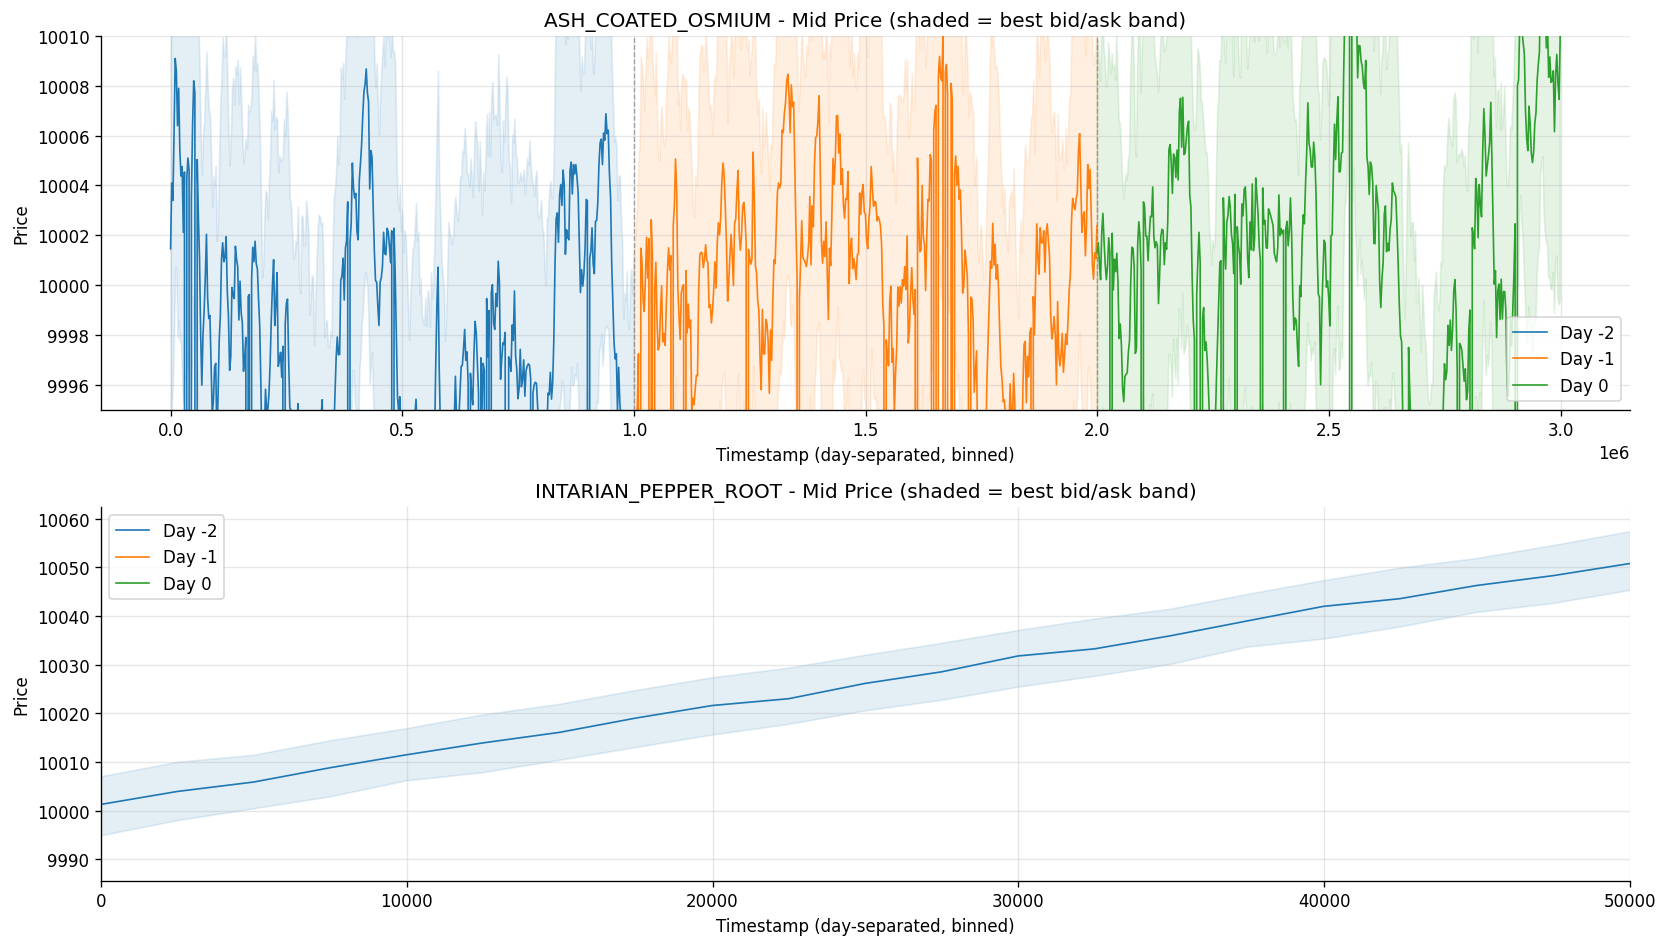

In [2]:
n = len(products)
fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n), sharex=False)
if n == 1:
    axes = [axes]

days = sorted(prices["day"].unique())
ts_min = prices["timestamp"].min()
ts_span = prices["timestamp"].max() - ts_min + 1
day_offset = {day: i * ts_span for i, day in enumerate(days)}
BIN_SIZE = max(100, int(ts_span / 400))

for ax, product in zip(axes, products):
    for day, grp in prices[prices["product"] == product].groupby("day"):
        grp = grp.sort_values("timestamp").drop_duplicates("timestamp", keep="last")
        binned = (
            grp.assign(ts_bin=(grp["timestamp"] // BIN_SIZE) * BIN_SIZE)
               .groupby("ts_bin", as_index=False)
               .agg(
                   mid_price=("mid_price", "mean"),
                   bid_price_1=("bid_price_1", "mean"),
                   ask_price_1=("ask_price_1", "mean"),
               )
        )
        x = binned["ts_bin"] - ts_min + day_offset[day]
        ax.plot(x, binned["mid_price"],
                color=DAY_COLORS[day], lw=1, label=f"Day {day}")
        ax.fill_between(x, binned["bid_price_1"], binned["ask_price_1"],
                        color=DAY_COLORS[day], alpha=0.12)

    for i, day in enumerate(days):
        if i > 0:
            ax.axvline(i * ts_span, color="gray", lw=0.8, linestyle="--", alpha=0.7)

    if product == "ASH_COATED_OSMIUM":
        ax.set_ylim(9995, 10010)

    if product == "INTARIAN_PEPPER_ROOT":
        x_max = 50000
        ax.set_xlim(0, x_max)
        # Compute ylim from data visible within the x window
        visible = []
        for day, grp in prices[prices["product"] == product].groupby("day"):
            grp = grp.sort_values("timestamp")
            x_vals = grp["timestamp"] - ts_min + day_offset[day]
            mask = x_vals <= x_max
            if mask.any():
                visible.append(grp[mask])
        if visible:
            vdf = pd.concat(visible)
            ymin = vdf["bid_price_1"].min(skipna=True)
            ymax = vdf["ask_price_1"].max(skipna=True)
            pad = (ymax - ymin) * 0.1 or 5
            ax.set_ylim(ymin - pad, ymax + pad)

    ax.set_title(f"{product} - Mid Price (shaded = best bid/ask band)", fontsize=12)
    ax.set_ylabel("Price")
    ax.set_xlabel("Timestamp (day-separated, binned)")
    ax.legend()

plt.tight_layout()
plt.show()

## 2 — Bid-Ask Spread Over Time

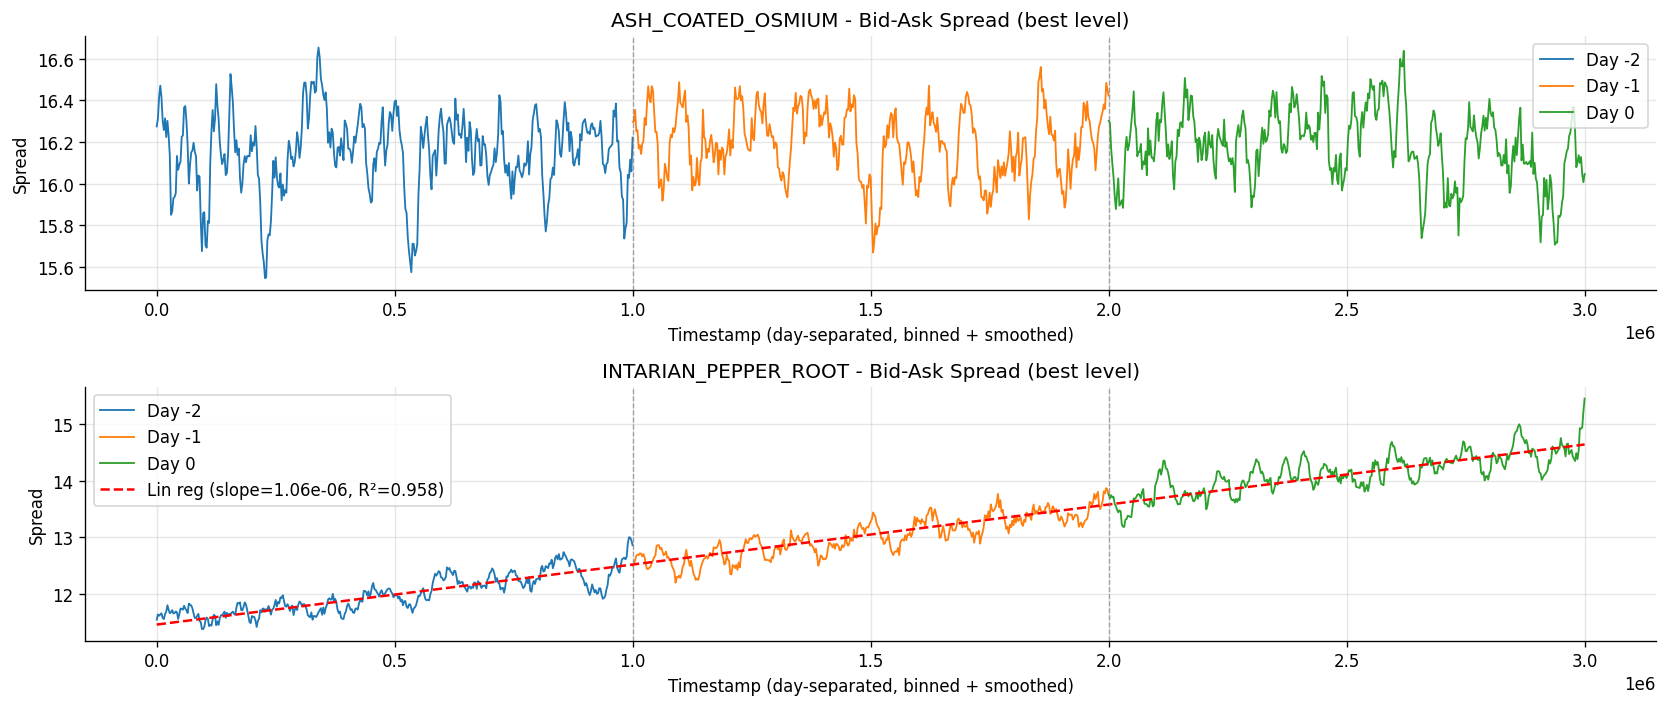

In [3]:
fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=False)
if n == 1:
    axes = [axes]

days = sorted(prices["day"].unique())
ts_min = prices["timestamp"].min()
ts_span = prices["timestamp"].max() - ts_min + 1
day_offset = {day: i * ts_span for i, day in enumerate(days)}
BIN_SIZE = max(100, int(ts_span / 400))
SMOOTH_WINDOW = 9

for ax, product in zip(axes, products):
    all_x, all_spread = [], []

    for day, grp in prices[prices["product"] == product].groupby("day"):
        grp = grp.sort_values("timestamp").drop_duplicates("timestamp", keep="last")
        binned = (
            grp.assign(ts_bin=(grp["timestamp"] // BIN_SIZE) * BIN_SIZE)
               .groupby("ts_bin", as_index=False)
               .agg(spread=("spread", "mean"))
        )
        binned["spread_smooth"] = (
            binned["spread"].rolling(SMOOTH_WINDOW, center=True, min_periods=1).mean()
        )
        x = binned["ts_bin"] - ts_min + day_offset[day]
        ax.plot(x, binned["spread_smooth"],
                color=DAY_COLORS[day], lw=1.1, label=f"Day {day}")

        if product == "INTARIAN_PEPPER_ROOT":
            valid = binned["spread_smooth"].notna()
            all_x.extend(x[valid].tolist())
            all_spread.extend(binned["spread_smooth"][valid].tolist())

    if product == "INTARIAN_PEPPER_ROOT" and len(all_x) > 1:
        slope, intercept, r, _, _ = sp_stats.linregress(all_x, all_spread)
        x_arr = np.array(all_x)
        ax.plot(x_arr, intercept + slope * x_arr,
                color="red", lw=1.5, linestyle="--",
                label=f"Lin reg (slope={slope:.2e}, R²={r**2:.3f})")

    for i, day in enumerate(days):
        if i > 0:
            ax.axvline(i * ts_span, color="gray", lw=0.8, linestyle="--", alpha=0.7)

    ax.set_title(f"{product} - Bid-Ask Spread (best level)", fontsize=12)
    ax.set_ylabel("Spread")
    ax.set_xlabel("Timestamp (day-separated, binned + smoothed)")
    ax.legend()

plt.tight_layout()
plt.show()

## 3 — Rolling Volatility (std of mid-price returns)

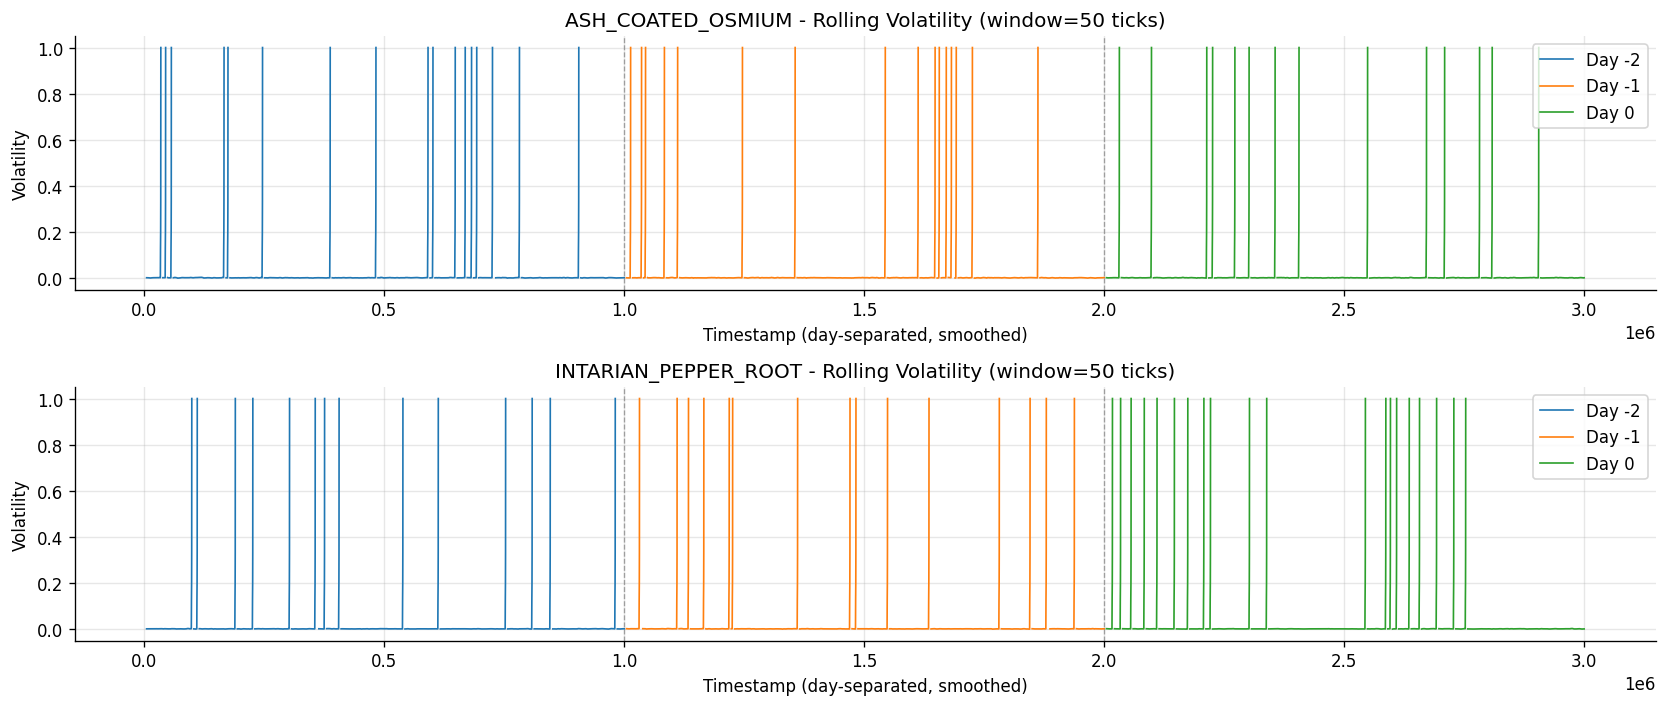

In [4]:
WINDOW = 50
VOL_SMOOTH_WINDOW = 10

fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=False)
if n == 1:
    axes = [axes]

days = sorted(prices["day"].unique())
ts_min = prices["timestamp"].min()
ts_span = prices["timestamp"].max() - ts_min + 1
day_offset = {day: i * ts_span for i, day in enumerate(days)}

for ax, product in zip(axes, products):
    for day, grp in prices[prices["product"] == product].groupby("day"):
        grp = grp.sort_values("timestamp").drop_duplicates("timestamp", keep="last")
        returns = grp["mid_price"].pct_change()
        rolling_vol = returns.rolling(WINDOW).std() * np.sqrt(WINDOW)
        rolling_vol_smooth = rolling_vol.rolling(VOL_SMOOTH_WINDOW, center=True, min_periods=1).mean()
        x = grp["timestamp"] - ts_min + day_offset[day]
        ax.plot(x.values, rolling_vol_smooth.values,
                color=DAY_COLORS[day], lw=1.0, label=f"Day {day}")

    for i, day in enumerate(days):
        if i > 0:
            ax.axvline(i * ts_span, color="gray", lw=0.8, linestyle="--", alpha=0.7)

    ax.set_title(f"{product} - Rolling Volatility (window={WINDOW} ticks)", fontsize=12)
    ax.set_ylabel("Volatility")
    ax.set_xlabel("Timestamp (day-separated, smoothed)")
    ax.legend()

plt.tight_layout()
plt.show()

## 4 — Order Book Depth (stacked bid/ask volumes)

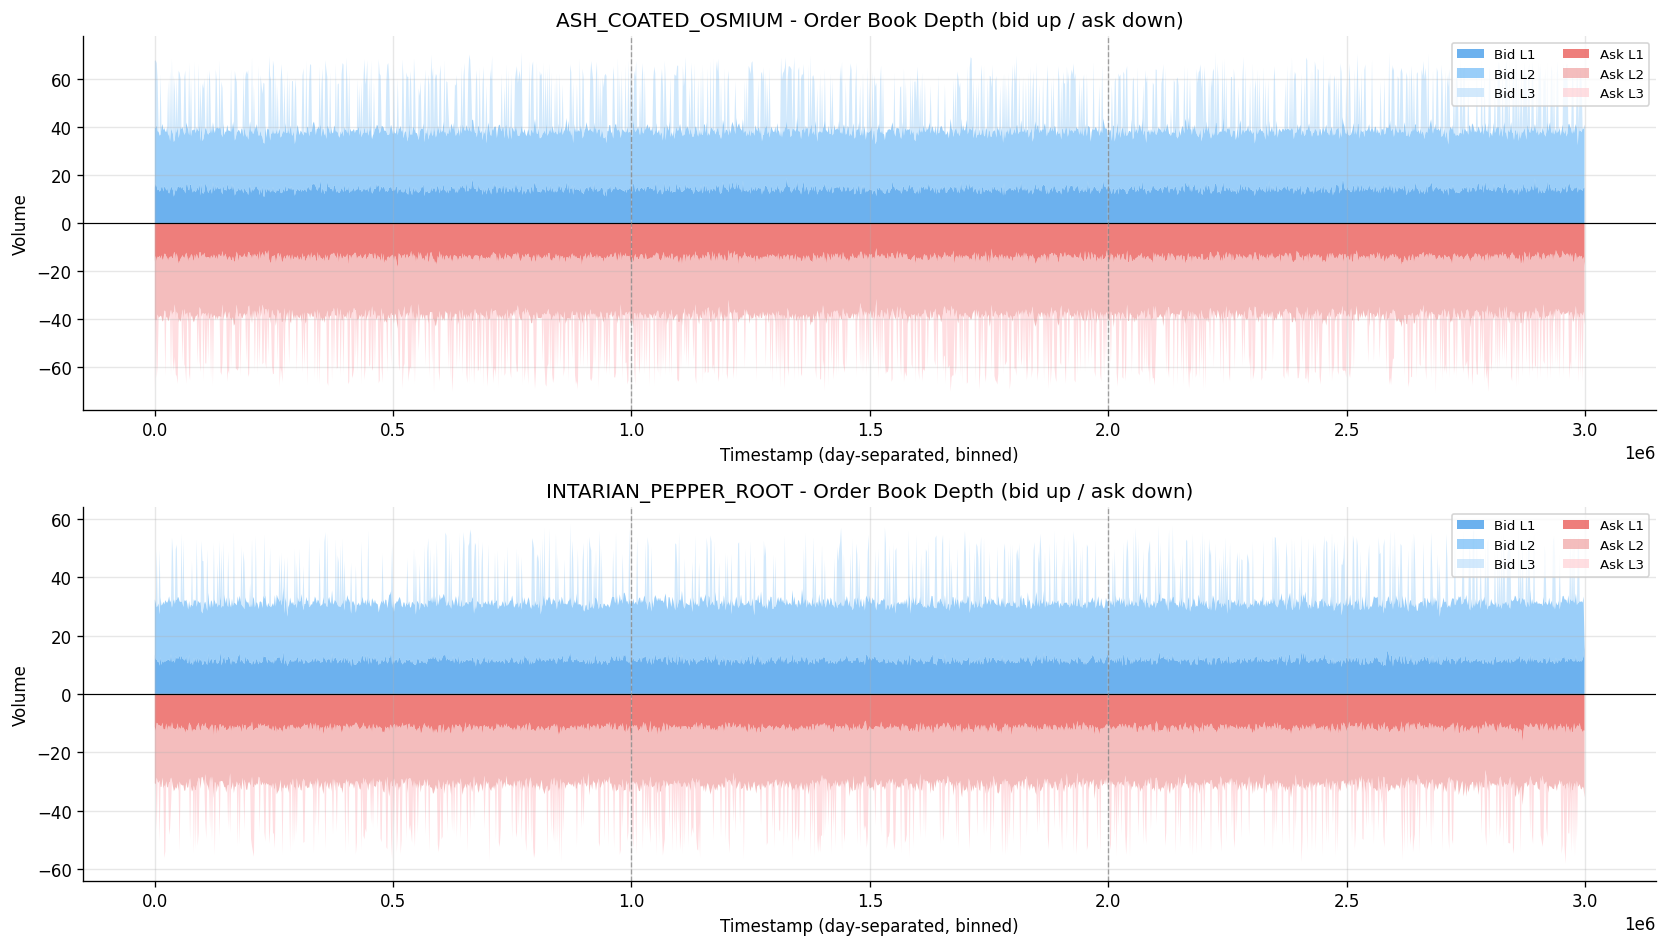

In [5]:
fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n), sharex=False)
if n == 1:
    axes = [axes]

days = sorted(prices["day"].unique())
ts_min = prices["timestamp"].min()
ts_span = prices["timestamp"].max() - ts_min + 1
day_offset = {day: i * ts_span for i, day in enumerate(days)}
BIN_SIZE = max(100, int(ts_span / 500))

for ax, product in zip(axes, products):
    for day in days:
        grp = prices[(prices["product"] == product) & (prices["day"] == day)]
        grp = grp.sort_values("timestamp").drop_duplicates("timestamp", keep="last")
        binned = (
            grp.assign(ts_bin=(grp["timestamp"] // BIN_SIZE) * BIN_SIZE)
               .groupby("ts_bin", as_index=False)
               .agg(
                   b1=("bid_volume_1", "mean"),
                   b2=("bid_volume_2", "mean"),
                   b3=("bid_volume_3", "mean"),
                   a1=("ask_volume_1", "mean"),
                   a2=("ask_volume_2", "mean"),
                   a3=("ask_volume_3", "mean"),
               )
               .fillna(0)
        )
        x = binned["ts_bin"] - ts_min + day_offset[day]
        bid_labels = ["Bid L1", "Bid L2", "Bid L3"] if day == days[0] else [None, None, None]
        ask_labels = ["Ask L1", "Ask L2", "Ask L3"] if day == days[0] else [None, None, None]
        ax.stackplot(x, binned["b1"], binned["b2"], binned["b3"],
                     labels=bid_labels,
                     colors=["#1E88E5", "#64B5F6", "#BBDEFB"], alpha=0.65)
        ax.stackplot(x, -binned["a1"], -binned["a2"], -binned["a3"],
                     labels=ask_labels,
                     colors=["#E53935", "#EF9A9A", "#FFCDD2"], alpha=0.65)

    ax.axhline(0, color="black", lw=0.7)
    for i, day in enumerate(days):
        if i > 0:
            ax.axvline(i * ts_span, color="gray", lw=0.8, linestyle="--", alpha=0.7)

    ax.set_title(f"{product} - Order Book Depth (bid up / ask down)", fontsize=12)
    ax.set_ylabel("Volume")
    ax.set_xlabel("Timestamp (day-separated, binned)")
    ax.legend(loc="upper right", ncol=2, fontsize=8, frameon=True)

plt.tight_layout()
plt.show()

## 5 — Mid-Price Return Distribution

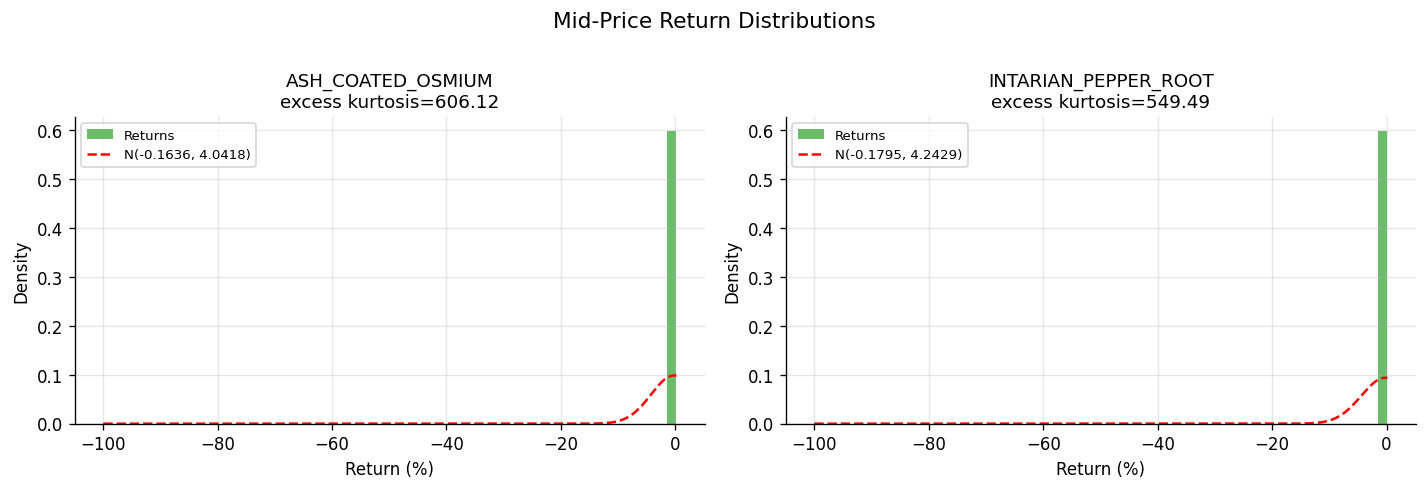

In [6]:
fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
if n == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    sub = prices[prices["product"] == product].sort_values(["day", "timestamp"])
    rets = sub["mid_price"].pct_change().dropna() * 100
    rets = rets.replace([np.inf, -np.inf], np.nan).dropna()
    ax.hist(rets, bins=60, density=True, color=COLORS[2], alpha=0.7, label="Returns")
    mu, sigma = rets.mean(), rets.std()
    x = np.linspace(rets.min(), rets.max(), 300)
    ax.plot(x, sp_stats.norm.pdf(x, mu, sigma), "r--", lw=1.5,
            label=f"N({mu:.4f}, {sigma:.4f})")
    kurt = sp_stats.kurtosis(rets)
    ax.set_title(f"{product}\nexcess kurtosis={kurt:.2f}", fontsize=11)
    ax.set_xlabel("Return (%)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Mid-Price Return Distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6 — Spread Distribution

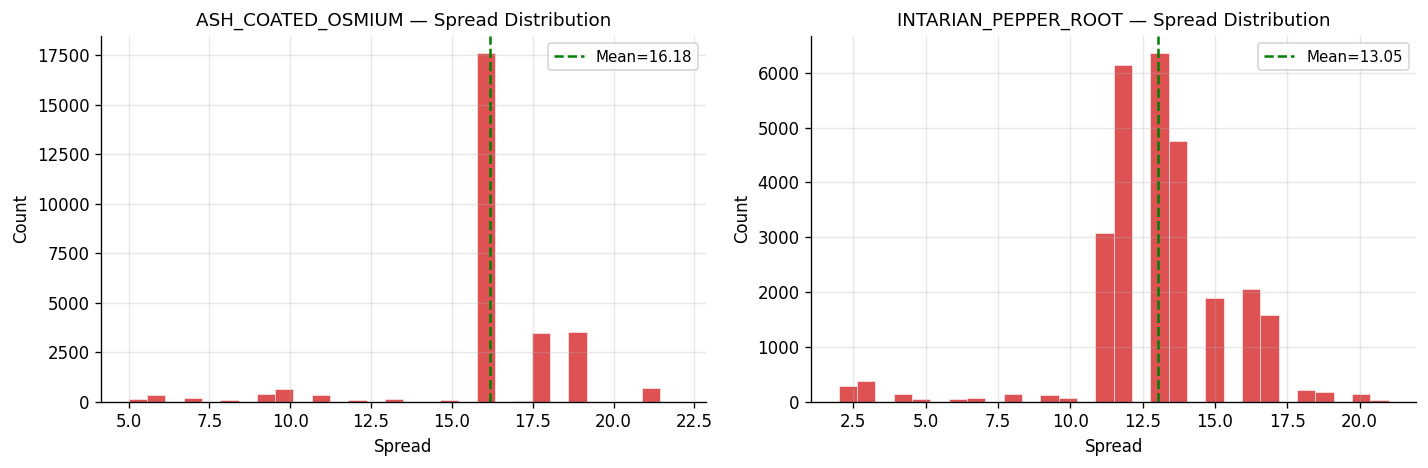

In [7]:
fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
if n == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    sub = prices[prices["product"] == product]
    spread_vals = sub["spread"].dropna()
    ax.hist(spread_vals, bins=30, color=COLORS[3], alpha=0.8, edgecolor="white", lw=0.4)
    ax.axvline(spread_vals.mean(), color="green", lw=1.5, linestyle="--",
               label=f"Mean={spread_vals.mean():.2f}")
    ax.set_title(f"{product} — Spread Distribution", fontsize=11)
    ax.set_xlabel("Spread")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7 — Order Book Imbalance Over Time

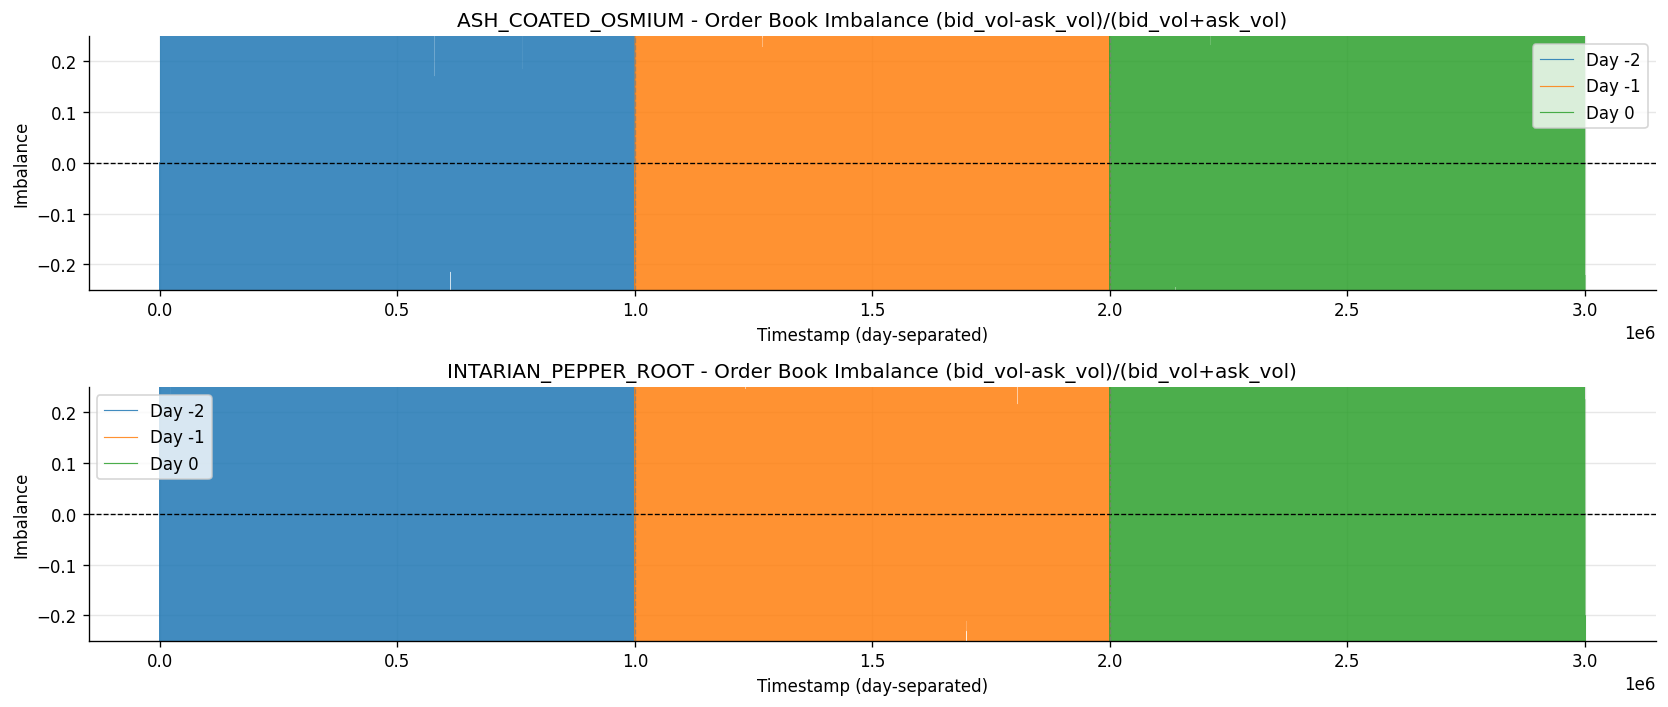

In [8]:
fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=False)
if n == 1:
    axes = [axes]

days = sorted(prices["day"].unique())
ts_min = prices["timestamp"].min()
ts_span = prices["timestamp"].max() - ts_min + 1
day_offset = {day: i * ts_span for i, day in enumerate(days)}

for ax, product in zip(axes, products):
    for day, grp in prices[prices["product"] == product].groupby("day"):
        grp = grp.sort_values("timestamp").drop_duplicates("timestamp", keep="last")
        x = grp["timestamp"] - ts_min + day_offset[day]
        ax.plot(x.values, grp["imbalance"].values,
                color=DAY_COLORS[day], lw=0.7, alpha=0.85, label=f"Day {day}")

    ax.axhline(0, color="black", lw=0.8, linestyle="--")
    for i, day in enumerate(days):
        if i > 0:
            ax.axvline(i * ts_span, color="gray", lw=0.8, linestyle="--", alpha=0.7)

    ax.set_ylim(-0.25, 0.25)
    ax.set_title(f"{product} - Order Book Imbalance (bid_vol-ask_vol)/(bid_vol+ask_vol)", fontsize=12)
    ax.set_ylabel("Imbalance")
    ax.set_xlabel("Timestamp (day-separated)")
    ax.legend()

plt.tight_layout()
plt.show()

## 8 — Trades — Price Track (color intensity = quantity)

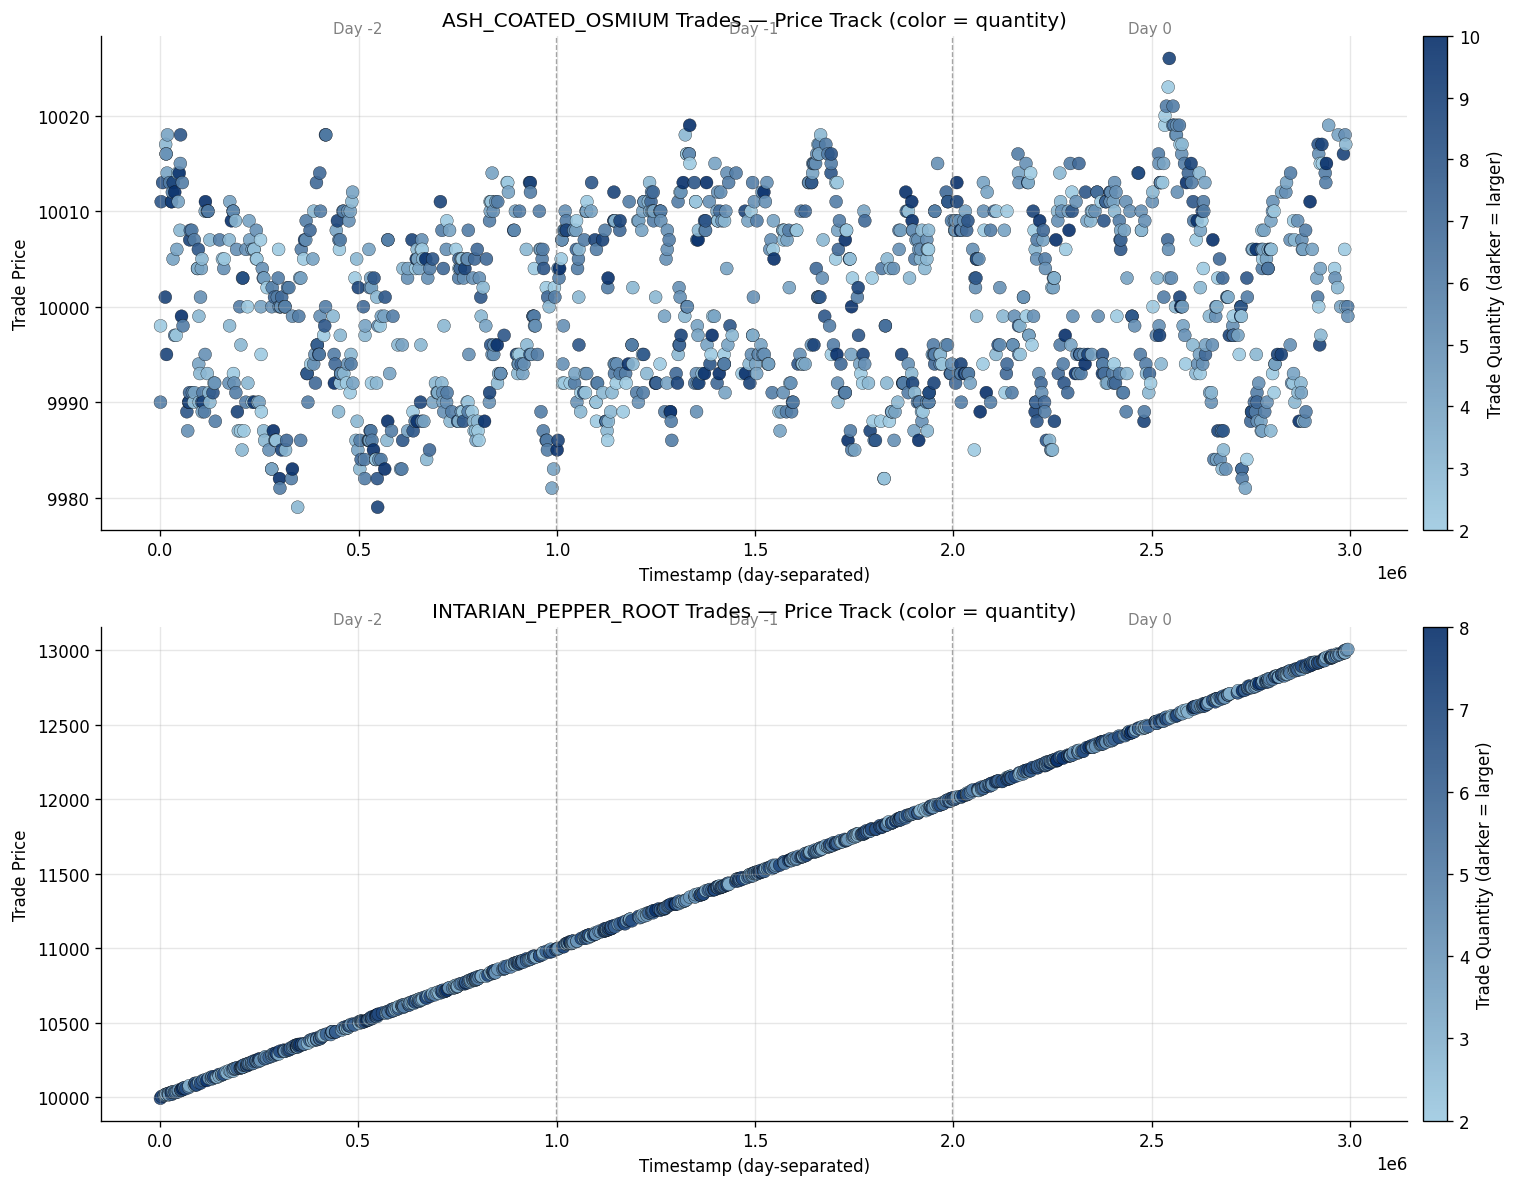

ASH_COATED_OSMIUM: 1265 trades | price range [9979.0, 10026.0]
INTARIAN_PEPPER_ROOT: 1011 trades | price range [9995.0, 13005.0]


In [9]:
days_t = sorted(trades["day"].unique())
ts_min_t = trades["timestamp"].min()
ts_span_t = trades["timestamp"].max() - ts_min_t + 1
day_offset_t = {day: i * ts_span_t for i, day in enumerate(days_t)}

trades["x"] = (
    trades["timestamp"] - ts_min_t + trades["day"].map(day_offset_t)
)

trade_products = sorted(trades["symbol"].unique())
n_tp = len(trade_products)
fig, axes = plt.subplots(n_tp, 1, figsize=(14, 5 * n_tp), sharex=False)
if n_tp == 1:
    axes = [axes]

for ax, product in zip(axes, trade_products):
    sub = trades[trades["symbol"] == product].copy()
    if sub.empty:
        ax.set_title(f"{product} — no trades")
        continue

    qmin, qmax = sub["quantity"].min(), sub["quantity"].max()
    qty_cmap = LinearSegmentedColormap.from_list("qty", ["#9ecae1", "#08306b"])

    sc = ax.scatter(
        sub["x"], sub["price"],
        c=sub["quantity"], cmap=qty_cmap, vmin=qmin, vmax=qmax,
        s=60, alpha=0.9,
        edgecolor="black", linewidth=0.2,
    )

    for i, day in enumerate(days_t):
        if i > 0:
            ax.axvline(i * ts_span_t, color="gray", lw=0.8, linestyle="--", alpha=0.7)

    cbar = plt.colorbar(sc, ax=ax, pad=0.01)
    cbar.set_label("Trade Quantity (darker = larger)")

    # Add day labels along the x-axis
    for i, day in enumerate(days_t):
        mid_x = i * ts_span_t + ts_span_t / 2
        ax.text(mid_x, ax.get_ylim()[1], f"Day {day}",
                ha="center", va="bottom", fontsize=9, color="gray")

    ax.set_title(f"{product} Trades — Price Track (color = quantity)", fontsize=12)
    ax.set_ylabel("Trade Price")
    ax.set_xlabel("Timestamp (day-separated)")

plt.tight_layout()
plt.show()

for product in trade_products:
    sub = trades[trades["symbol"] == product]
    print(f"{product}: {len(sub)} trades | price range [{sub['price'].min():.1f}, {sub['price'].max():.1f}]")

## 9 — Summary Statistics

In [10]:
rows = []
for product in products:
    sub = prices[prices["product"] == product].sort_values(["day", "timestamp"])
    rets = sub["mid_price"].pct_change().dropna() * 100
    rows.append({
        "Product": product,
        "Mid Mean": sub["mid_price"].mean(),
        "Mid Std": sub["mid_price"].std(),
        "Mid Min": sub["mid_price"].min(),
        "Mid Max": sub["mid_price"].max(),
        "Return Mean (%)": rets.mean(),
        "Return Std (%)": rets.std(),
        "Kurtosis": sp_stats.kurtosis(rets),
        "Mean Spread": sub["spread"].mean(),
        "Mean Bid Vol": sub["bid_vol_total"].mean(),
        "Mean Ask Vol": sub["ask_vol_total"].mean(),
    })

summary = pd.DataFrame(rows).set_index("Product")
pd.set_option("display.float_format", "{:.4f}".format)
summary

/Users/richardshi/Documents/IMC_Prosperity/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/richardshi/Documents/IMC_Prosperity/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1162: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean
/Users/richardshi/Documents/IMC_Prosperity/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/richardshi/Documents/IMC_Prosperity/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1162: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


,Mid Mean,Mid Std,Mid Min,Mid Max,Return Mean (%),Return Std (%),Kurtosis,Mean Spread,Mean Bid Vol,Mean Ask Vol
Product,,,,,,,,,,
ASH_COATED_OSMIUM,9983.8706,403.8654,0.0000,10023.0000,inf,NaN,NaN,16.1752,30.1074,30.1607
INTARIAN_PEPPER_ROOT,11479.1887,993.1848,0.0000,13007.0000,inf,NaN,NaN,13.0467,24.1425,24.2262
